# Reinforcement Learning with Q-Learning: FrozenLake-v1 Demonstration

## Objective

This notebook provides a step-by-step introduction to Reinforcement Learning (RL) using the Q-Learning algorithm within the Gymnasium environment. The primary goal is to demonstrate how an intelligent agent can learn to navigate a simple environment to achieve a specific goal through trial and error.

**What to expect:**
*   **Environment Setup**: We'll begin by setting up a classic RL environment from the Gymnasium library.
*   **Q-Learning Principles**: An explanation of the core concepts of Q-Learning, including states, actions, rewards, and the Q-table update mechanism.
*   **Agent Training**: Implementation of the Q-Learning algorithm to train an agent to solve the chosen environment.
*   **Training Visualization**: How to visualize the agent's learning progress over time.
*   **Policy Evaluation**: Evaluating the learned policy and observing the agent's behavior, including an animated visual demonstration.

By following this notebook, you will gain a practical understanding of how Q-Learning works and how to apply it to a basic RL problem.

## The FrozenLake-v1 Environment

For this demonstration, we will be using the `FrozenLake-v1` environment from the Gymnasium library. This is a classic and simple grid-world environment, ideal for understanding basic RL concepts.

**Environment Description:**

*   **Grid Size**: Typically a 4x4 grid (though larger versions exist).
*   **States**: Each tile on the grid represents a unique state. The states are usually numbered from 0 to 15 for a 4x4 grid.
    *   `S`: Start position (safe)
    *   `F`: Frozen surface (safe)
    *   `H`: Hole (agent falls, episode ends, reward of 0)
    *   `G`: Goal (agent reaches, episode ends, reward of 1)
*   **Actions**: The agent can choose one of four actions:
    *   0: LEFT
    *   1: DOWN
    *   2: RIGHT
    *   3: UP
*   **Slipperiness**: For simplicity, we will initially set `is_slippery=False`, meaning that taking an action always moves the agent in the intended direction. This makes the environment deterministic. A `is_slippery=True` environment would introduce stochasticity, where actions might randomly result in movement in an unintended direction.
*   **Reward System**:
    *   Reaching the Goal (`G`): +1 reward.
    *   Falling into a Hole (`H`): 0 reward.
    *   Moving on Frozen (`F`) or Start (`S`) tiles: 0 reward.

The agent's objective is to find a path from the start `S` to the goal `G` while avoiding holes `H`, maximizing its cumulative reward.

In [ ]:
print("\nInitial FrozenLake-v1 Environment Grid:\n")
print(env.unwrapped.desc)


Initial FrozenLake-v1 Environment Grid:

[[b'S' b'F' b'F' b'F']
 [b'F' b'H' b'F' b'H']
 [b'F' b'F' b'F' b'H']
 [b'H' b'F' b'F' b'G']]


Attempting to display image from: /content/drive/MyDrive/RL_Project/rl_animations/frozenlake_initial_frame.png


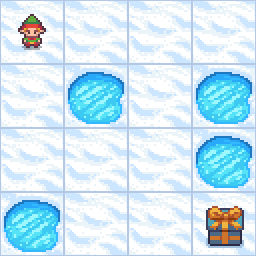

Image should be displayed above.


In [ ]:
from IPython.display import Image, display
import os

image_path = '/content/drive/MyDrive/RL_Project/rl_animations/frozenlake_initial_frame.png'

print(f"Attempting to display image from: {image_path}")

# Check if the file exists before attempting to display it
if os.path.exists(image_path):
    try:
        display(Image(filename=image_path))
        print("Image should be displayed above.")
    except Exception as e:
        print(f"An error occurred while displaying the image: {e}")
else:
    print(f"Error: Image file not found at {image_path}. Please ensure it has been copied to Google Drive.")

## Set up the environment

In [ ]:
import gymnasium as gym
import numpy as np
import time

# 1. Environment Setup: FrozenLake-v1
# --------------------------------------------------------------------------------

# Install gymnasium if not already installed (uncomment and run if needed)
# !pip install gymnasium

print("Setting up the FrozenLake-v1 environment...")

# Create the FrozenLake-v1 environment.
# 'is_slippery=False' makes it a deterministic environment, which is easier to learn initially.
# For a more challenging environment, remove is_slippery=False.
env = gym.make('FrozenLake-v1', is_slippery=False, render_mode='ansi')

# Get information about the observation and action spaces
observation_space_size = env.observation_space.n
action_space_size = env.action_space.n

print(f"Observation Space Size (Number of states): {observation_space_size}")
print(f"Action Space Size (Number of actions): {action_space_size}")
print("Each state represents a tile on the 4x4 grid (0-15).")
print("Actions: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP\n")

# 2. Q-Table Initialization
# --------------------------------------------------------------------------------

# Initialize the Q-table with zeros.
# The Q-table will store the expected future rewards for taking an action in a given state.
# Its dimensions are (number of states x number of actions).
q_table = np.zeros((observation_space_size, action_space_size))

print("Q-table initialized with zeros. Shape: ", q_table.shape)
print("This table will be updated during the training process.\n")

# Example of how the Q-table looks initially (first few rows)
# print("Initial Q-table (first 5 rows):\n", q_table[:5, :])

Setting up the FrozenLake-v1 environment...
Observation Space Size (Number of states): 16
Action Space Size (Number of actions): 4
Each state represents a tile on the 4x4 grid (0-15).
Actions: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP

Q-table initialized with zeros. Shape:  (16, 4)
This table will be updated during the training process.



### 3. Q-Learning Algorithm Explained

Q-Learning is a model-free reinforcement learning algorithm. Its goal is to learn a policy, which tells an agent what action to take under what circumstances. It does this by learning an action-value function, often called `Q(s, a)`, which represents the expected total future reward when starting in state `s` and taking action `a`.

**Key Concepts:**

*   **Q-Table**: This is a lookup table where `Q(s, a)` values are stored. Rows represent states, and columns represent actions. The values indicate the 'quality' or desirability of taking a certain action in a given state.
*   **State (`s`)**: The current situation or configuration of the environment (e.g., the agent's position on the grid).
*   **Action (`a`)**: A move the agent can make (e.g., move left, right, up, down).
*   **Reward (`r`)**: A feedback signal from the environment indicating how good or bad an action was (e.g., +1 for reaching the goal, 0 for moving, -1 for falling in a hole).
*   **Episode**: A single complete run through the environment, from start to a terminal state (goal or failure).

**The Q-Learning Update Rule:**

The core of Q-Learning is how the `Q(s, a)` values are updated. After the agent takes an action `a` in state `s`, observes a reward `r`, and transitions to a new state `s'`, the Q-value for the original state-action pair is updated using the following formula:

```
Q(s, a) := Q(s, a) + α * [r + γ * max(Q(s', a')) - Q(s, a)]
```

Where:
*   `Q(s, a)`: The current estimated value of taking action `a` in state `s`.
*   `α` (alpha): The **learning rate** (0 < α ≤ 1). This determines how much new information (the new estimate) overrides old information. A value of 0 means the agent learns nothing, while a value of 1 means the agent only considers the most recent information.
*   `r`: The immediate **reward** received after taking action `a` in state `s`.
*   `γ` (gamma): The **discount factor** (0 ≤ γ ≤ 1). This determines the importance of future rewards. A value of 0 makes the agent "short-sighted" (only cares about immediate rewards), while a value close to 1 makes it "long-sighted" (cares about future rewards).
*   `max(Q(s', a'))`: The maximum Q-value for the **new state `s'`**, representing the best possible future reward from that state. This is the "greedy" part of the update.
*   `Q(s, a)`: The old Q-value for the current state-action pair.

This update rule essentially teaches the agent by blending its current estimate of the value of an action with the new information it gained from experience (reward + discounted max future reward from the next state).

### 4. Q-Learning Training Implementation

Now we'll implement the core Q-Learning algorithm. This involves defining the learning parameters (hyperparameters), an action selection strategy (epsilon-greedy), and the main training loop.

In [ ]:
# 4.1. Define Hyperparameters
# --------------------------------------------------------------------------------

learning_rate = 0.9      # alpha (α): How much new information overrides old information.
discount_factor = 0.9    # gamma (γ): Importance of future rewards (0 = short-sighted, 1 = long-sighted).
epsilon = 1.0            # epsilon (ε): Exploration-exploitation trade-off. Starts at 1.0 (pure exploration).
max_epsilon = 1.0        # Upper bound for epsilon.
min_epsilon = 0.01       # Lower bound for epsilon.
decay_rate = 0.005       # Rate at which epsilon decays over episodes.

n_episodes = 20000       # Total number of training episodes.
max_steps_per_episode = 100  # Maximum number of steps per episode to prevent infinite loops.

print(f"Hyperparameters set: Learning Rate={learning_rate}, Discount Factor={discount_factor}, Episodes={n_episodes}\n")

Hyperparameters set: Learning Rate=0.9, Discount Factor=0.9, Episodes=20000



In [ ]:
# 4.2. Epsilon-Greedy Action Selection Function
# --------------------------------------------------------------------------------

def choose_action(state, q_table, epsilon):
    # Explore: Generate a random number. If it's less than epsilon, choose a random action.
    if np.random.uniform(0, 1) < epsilon:
        action = env.action_space.sample() # Take a random action
    # Exploit: If the random number is greater than epsilon, choose the action with the highest Q-value.
    else:
        # Get all actions with the maximum Q-value for the current state
        max_q = np.max(q_table[state, :])
        # Find indices where q_table[state, :] equals max_q
        possible_actions = np.where(q_table[state, :] == max_q)[0]
        # Choose randomly among these actions to break ties
        action = np.random.choice(possible_actions)
    return action

print("Epsilon-greedy action selection function defined (with tie-breaking for exploitation).\n")

Epsilon-greedy action selection function defined (with tie-breaking for exploitation).



In [ ]:
# 4.3. Q-Learning Training Loop
# --------------------------------------------------------------------------------

rewards_per_episode = []

print("Starting Q-Learning training...")

for episode in range(n_episodes):
    state, _ = env.reset() # Reset the environment for a new episode
    terminated = False     # Flag to check if the episode ended (goal reached or fell in hole)
    truncated = False      # Flag to check if the episode was truncated (max_steps reached)
    rewards_current_episode = 0

    for step in range(max_steps_per_episode):
        # Choose an action using the epsilon-greedy policy
        action = choose_action(state, q_table, epsilon)

        # Take the chosen action and observe the new state, reward, and done flags
        new_state, reward, terminated, truncated, _ = env.step(action)

        # Update the Q-table using the Q-Learning formula
        q_table[state, action] = q_table[state, action] + learning_rate * \
                                 (reward + discount_factor * np.max(q_table[new_state, :]) - q_table[state, action])

        # Move to the new state
        state = new_state
        rewards_current_episode += reward

        # If the episode is terminated or truncated, break the inner loop
        if terminated or truncated:
            break

    # Decay epsilon to reduce exploration over time
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)

    # Store the total reward for this episode
    rewards_per_episode.append(rewards_current_episode)

    # Print progress every 1000 episodes
    if (episode + 1) % 1000 == 0:
        print(f"Episode {episode + 1}/{n_episodes} - Epsilon: {epsilon:.2f} - Avg Reward (last 1000): {np.mean(rewards_per_episode[-1000:]):.2f}")

print("\nTraining complete!")
print("Final Q-table (first 5 rows):\n", q_table[:5, :])

# Optional: Close the environment
env.close()


Starting Q-Learning training...
Episode 1000/20000 - Epsilon: 0.02 - Avg Reward (last 1000): 0.75
Episode 2000/20000 - Epsilon: 0.01 - Avg Reward (last 1000): 0.99
Episode 3000/20000 - Epsilon: 0.01 - Avg Reward (last 1000): 0.99
Episode 4000/20000 - Epsilon: 0.01 - Avg Reward (last 1000): 0.98
Episode 5000/20000 - Epsilon: 0.01 - Avg Reward (last 1000): 0.99
Episode 6000/20000 - Epsilon: 0.01 - Avg Reward (last 1000): 0.99
Episode 7000/20000 - Epsilon: 0.01 - Avg Reward (last 1000): 0.99
Episode 8000/20000 - Epsilon: 0.01 - Avg Reward (last 1000): 0.99
Episode 9000/20000 - Epsilon: 0.01 - Avg Reward (last 1000): 1.00
Episode 10000/20000 - Epsilon: 0.01 - Avg Reward (last 1000): 0.99
Episode 11000/20000 - Epsilon: 0.01 - Avg Reward (last 1000): 0.99
Episode 12000/20000 - Epsilon: 0.01 - Avg Reward (last 1000): 0.99
Episode 13000/20000 - Epsilon: 0.01 - Avg Reward (last 1000): 0.99
Episode 14000/20000 - Epsilon: 0.01 - Avg Reward (last 1000): 0.99
Episode 15000/20000 - Epsilon: 0.01 - A

### 7. Detailed Analysis of the Learned Q-Table

The Q-table is the heart of our trained agent. It stores the maximum expected future reward for taking a particular action in a particular state. By examining its values, we can understand the learned policy and how the agent intends to move through the environment.

**Interpreting the Q-Table:**

*   **Rows represent States (0-15)**: Each row corresponds to one of the 16 tiles on the 4x4 FrozenLake grid.
*   **Columns represent Actions (0-3)**: Each column corresponds to an action:
    *   `0`: LEFT
    *   `1`: DOWN
    *   `2`: RIGHT
    *   `3`: UP
*   **Values**: A higher value in a `Q(state, action)` cell indicates that taking that action from that state is expected to lead to a greater cumulative future reward. The agent's optimal policy is to always choose the action with the highest Q-value in its current state.

In [ ]:
import numpy as np

# Define action mapping for better readability
action_map = {0: 'LEFT', 1: 'DOWN', 2: 'RIGHT', 3: 'UP'}

print("\n--- Learned Q-Table ---\n")
print(q_table)

print("\n--- Analysis of Key States ---\n")

# Analyze the starting state (State 0)
start_state = 0
print(f"State {start_state} (Start 'S'):")
print(f"  Q-values: {q_table[start_state]}")
best_action_index_start = np.argmax(q_table[start_state])
print(f"  Best Action: {action_map[best_action_index_start]} (Q-value: {q_table[start_state, best_action_index_start]:.4f})")

# Analyze a state leading to the Goal (e.g., State 14 which is F, one step left of G)
# Assuming Goal is state 15 in a 4x4 grid. State 14 is the one just before it.
# In the provided grid: [[b'S' b'F' b'F' b'F'], [b'F' b'H' b'F' b'H'], [b'F' b'F' b'F' b'H'], [b'H' b'F' b'F' b'G']]
# State 14 is F, just before G(15).

# Find the goal state (assuming it's 'G')
grid = env.unwrapped.desc.astype('U')
goal_state = -1
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        if grid[i, j] == 'G':
            goal_state = i * grid.shape[1] + j
            break
    if goal_state != -1: break

if goal_state != -1:
    print(f"\nState {goal_state} (Goal 'G'):")
    print(f"  Q-values: {q_table[goal_state]}")
    # Q-values for goal state should theoretically be 0 as no more actions can be taken, or just reflect the reward
    # However, sometimes small non-zero values might accumulate due to update rules or final reward. Max should be close to 0.
    if np.max(q_table[goal_state]) > 0:
        best_action_index_goal = np.argmax(q_table[goal_state])
        print(f"  Best Action: {action_map[best_action_index_goal]} (Q-value: {q_table[goal_state, best_action_index_goal]:.4f}) (Theoretically, no actions from goal state)")
    else:
        print("  Q-values are all zero or negligible, as expected for a terminal state.")

    # Analyze states adjacent to the goal
    # Example: state 14, if it leads to 15 (G) by action RIGHT
    # The exact state leading to G depends on the grid and path. For our example, let's pick 14.
    # In a 4x4 grid, state 14 is (3,2). Action RIGHT (2) from state 14 leads to state 15 (3,3=G).
    state_before_goal = 14 # State (3,2) in a 4x4 grid
    print(f"\nState {state_before_goal} (F, leading to G):")
    print(f"  Q-values: {q_table[state_before_goal]}")
    best_action_index_before_goal = np.argmax(q_table[state_before_goal])
    print(f"  Best Action: {action_map[best_action_index_before_goal]} (Q-value: {q_table[state_before_goal, best_action_index_before_goal]:.4f})")

# Analyze a state adjacent to a Hole (e.g., State 13, which is F, one step left of 12 (H) in provided grid)
# State 13 is (3,1). Action RIGHT from 13 leads to 14 (F), not a hole directly. Let's pick 7 instead, which is F, above H(11).
# From 7 (1,3), DOWN (1) leads to 11 (2,3) which is H. From 6 (1,2), RIGHT (2) leads to 7 (1,3).
# Let's check a state that has low Q-values for actions leading to a hole.
# State 11 is H. So states 7 (UP), 10 (LEFT), 12 (RIGHT) and 15 (DOWN) could lead to it
# In our grid: State 7 is F, and going DOWN (action 1) from state 7 leads to state 11 (Hole). Its Q-value for DOWN should be low.
hole_adjacent_state = 7 # State (1,3)
print(f"\nState {hole_adjacent_state} (F, adjacent to a Hole):")
print(f"  Q-values: {q_table[hole_adjacent_state]}")
best_action_index_hole_adj = np.argmax(q_table[hole_adjacent_state])
print(f"  Best Action: {action_map[best_action_index_hole_adj]} (Q-value: {q_table[hole_adjacent_state, best_action_index_hole_adj]:.4f})")
print(f"  Note: Q-value for DOWN ({action_map[1]}) from state {hole_adjacent_state} (leading to a hole) is: {q_table[hole_adjacent_state, 1]:.4f}")


--- Learned Q-Table ---

[[0.531441   0.59049    0.59049    0.531441  ]
 [0.531441   0.         0.6561     0.59049   ]
 [0.59049    0.729      0.59049    0.6561    ]
 [0.6561     0.         0.58989886 0.59043094]
 [0.59049    0.6561     0.         0.531441  ]
 [0.         0.         0.         0.        ]
 [0.         0.81       0.         0.6561    ]
 [0.         0.         0.         0.        ]
 [0.6561     0.         0.729      0.59049   ]
 [0.6561     0.81       0.81       0.        ]
 [0.729      0.9        0.         0.729     ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.8098461  0.9        0.72899993]
 [0.81       0.9        1.         0.81      ]
 [0.         0.         0.         0.        ]]

--- Analysis of Key States ---

State 0 (Start 'S'):
  Q-values: [0.531441 0.59049  0.59049  0.531441]
  Best Action: DOWN (Q-value: 0.5905)

State 15 (Goal 'G'):
  Q-values: [0. 0. 0. 0.]
  Q-values are all zero or negl

### Addressing Learning Stalling in Deterministic Environments

During the initial training phase, especially when the Q-table is initialized with all zeros, a common issue can arise in deterministic environments. When `np.argmax(q_table[state, :])` is used for exploitation, if all Q-values for a given state are identical (e.g., all 0), `np.argmax` deterministically returns the index of the *first* occurrence of the maximum value (which is typically action 0).

If repeatedly choosing action 0 from the starting state (or any state) does not lead to a reward, the Q-table entries will never get updated, and the agent can get stuck in a pattern of non-learning. This means the exploration phase might not be sufficient to find a rewarding path.

To compensate for this, the `choose_action` function was modified to include **random tie-breaking** during the exploitation phase:

```python
# Inside the 'else' block (exploitation phase) of choose_action:
max_q = np.max(q_table[state, :])
possible_actions = np.where(q_table[state, :] == max_q)[0]
action = np.random.choice(possible_actions)
```

This change ensures that when multiple actions share the highest Q-value (most commonly, all zeros initially), the agent will randomly select among them. This increased randomness during early exploitation allows the agent a better chance to stumble upon a rewarding path, which then kickstarts the Q-table updates and enables effective learning.

The training loop has completed! The Q-table has now been updated based on the agent's experiences. You can see the initial rows of the learned Q-table above.

Next, we can visualize the training progress and evaluate the learned policy.

### 5. Visualize Training Progress

To understand how well our agent learned, we can plot the rewards accumulated per episode over time. This helps visualize the learning curve and identify if the agent's performance improved and stabilized.

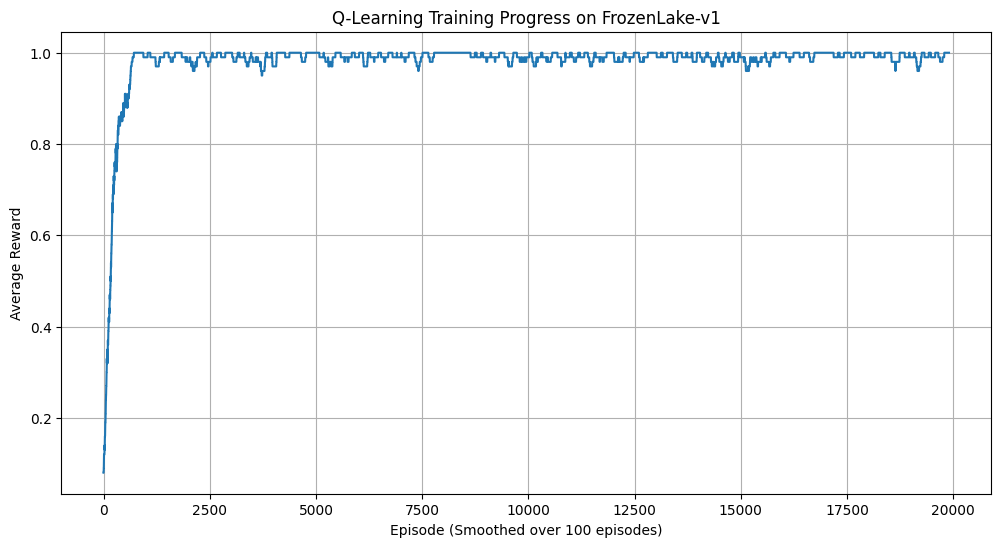

Training progress plotted. The average reward over the last 100 episodes is: 1.00


In [ ]:
import matplotlib.pyplot as plt

# Calculate average rewards for smoother plotting
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size), 'valid') / window_size

window_size = 100 # Average over 100 episodes
smoothed_rewards = moving_average(rewards_per_episode, window_size)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.plot(range(len(smoothed_rewards)), smoothed_rewards)
plt.xlabel('Episode (Smoothed over {} episodes)'.format(window_size))
plt.ylabel('Average Reward')
plt.title('Q-Learning Training Progress on FrozenLake-v1')
plt.grid(True)
plt.show()

print(f"Training progress plotted. The average reward over the last {window_size} episodes is: {np.mean(rewards_per_episode[-window_size:]):.2f}")

### 6. Evaluate the Learned Policy (with Rendering)

Now that our Q-table is trained, let's evaluate how well the agent performs. We'll run the agent for a few episodes, choosing actions based purely on the learned Q-values (exploitation). We'll also enable rendering to visualize the agent's journey.

In [ ]:
import imageio
from IPython.display import Image # Used to display GIF in Colab

# Create a new environment instance with rendering enabled for RGB array
eval_env = gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array')

n_evaluation_episodes = 1 # Number of episodes to evaluate for GIF (kept low for file size)
total_rewards_eval = []
frames = [] # List to store frames for GIF

print(f"\nEvaluating the learned policy over {n_evaluation_episodes} episode for GIF generation...")

for episode in range(n_evaluation_episodes):
    state, info = eval_env.reset()
    terminated = False
    truncated = False
    episode_reward = 0
    step_count = 0

    print(f"\n--- Evaluation Episode {episode + 1} ---")
    frames.append(eval_env.render())

    while not terminated and not truncated:
        # Choose action greedily (exploitation only, no exploration)
        action = np.argmax(q_table[state, :])

        new_state, reward, terminated, truncated, info = eval_env.step(action)
        episode_reward += reward
        state = new_state
        step_count += 1

        frames.append(eval_env.render())

    total_rewards_eval.append(episode_reward)
    print(f"Episode {episode + 1} finished. Reward: {episode_reward}, Steps: {step_count}")

# Close the evaluation environment
eval_env.close()

# Save frames as a GIF
gif_path = 'frozenlake_q_learning.gif'
imageio.mimsave(gif_path, frames, fps=10) # fps=10 to control animation speed

# Display the GIF in the notebook
print(f"\nGenerated GIF: {gif_path}")
Image(open(gif_path, 'rb').read())

print(f"\nAverage reward over {n_evaluation_episodes} evaluation episode: {np.mean(total_rewards_eval):.2f}")


Evaluating the learned policy over 1 episode for GIF generation...

--- Evaluation Episode 1 ---
Episode 1 finished. Reward: 1, Steps: 6

Generated GIF: frozenlake_q_learning.gif

Average reward over 1 evaluation episode: 1.00


Attempting to display GIF from: frozenlake_q_learning.gif


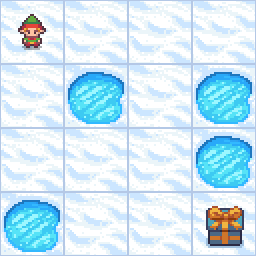

GIF should be displayed above.


In [ ]:
from IPython.display import Image, display

gif_path = 'frozenlake_q_learning.gif'

print(f"Attempting to display GIF from: {gif_path}")

try:
    with open(gif_path, 'rb') as f:
        display(Image(data=f.read()))
    print("GIF should be displayed above.")
except FileNotFoundError:
    print(f"Error: GIF file not found at {gif_path}. Please ensure the previous cell was run and generated the file.")
except Exception as e:
    print(f"An error occurred while displaying the GIF: {e}")

# First and final frames of the animation

Initial frame extracted and saved as 'frozenlake_initial_frame.png'.


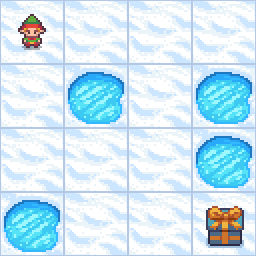

Image of the initial frame should be displayed above.


In [ ]:
import imageio

# Path to the previously created GIF
gif_path = 'frozenlake_q_learning.gif'

# Read all frames from the GIF
try:
    # Using imageio.mimread to get a list of numpy arrays (frames)
    gif_frames = imageio.mimread(gif_path)

    if gif_frames:
        # The first frame is the initial state
        initial_frame = gif_frames[0]

        # Define the output path for the image
        output_image_path = 'frozenlake_initial_frame.png'

        # Save the initial frame as a PNG image
        imageio.imwrite(output_image_path, initial_frame)

        print(f"Initial frame extracted and saved as '{output_image_path}'.")

        # Optionally, display the image in the notebook
        from IPython.display import Image, display
        display(Image(filename=output_image_path))
        print("Image of the initial frame should be displayed above.")
    else:
        print("Error: No frames found in the GIF.")

except FileNotFoundError:
    print(f"Error: GIF file not found at {gif_path}. Please ensure the GIF was generated successfully.")
except Exception as e:
    print(f"An error occurred while extracting the initial frame: {e}")

Final frame extracted and saved as 'frozenlake_final_frame.png'.


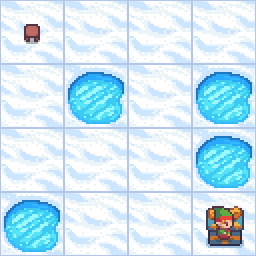

Image of the final frame should be displayed above.


In [ ]:
import imageio
from IPython.display import Image, display

# Path to the previously created GIF
gif_path = 'frozenlake_q_learning.gif'

try:
    # Read all frames from the GIF
    gif_frames = imageio.mimread(gif_path)

    if gif_frames:
        # The last frame is the final state
        final_frame = gif_frames[-1]

        # Define the output path for the image
        output_image_path = 'frozenlake_final_frame.png'

        # Save the final frame as a PNG image
        imageio.imwrite(output_image_path, final_frame)

        print(f"Final frame extracted and saved as '{output_image_path}'.")

        # Optionally, display the image in the notebook
        display(Image(filename=output_image_path))
        print("Image of the final frame should be displayed above.")
    else:
        print("Error: No frames found in the GIF.")

except FileNotFoundError:
    print(f"Error: GIF file not found at {gif_path}. Please ensure the GIF was generated successfully.")
except Exception as e:
    print(f"An error occurred while extracting the final frame: {e}")